In [60]:
# Для роботи з даними
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

# Для роботи з Keras
from tensorflow.keras.models import Sequential # модель прямого розповсюдження
from tensorflow.keras.layers import Dense # повнозв'язні прошарки

In [61]:
BASE_DIR = Path.cwd()
file_name = 'pokedex_b.csv'
DATA_PATH = BASE_DIR / 'data' / file_name

try:
    data = pd.read_csv(DATA_PATH)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")

data.head()

File loaded successfully.


,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,144,Articuno,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,145,Zapdos,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,146,Moltres,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,Mewtwo,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,151,Mew,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


Перевіряємо, наскільки збалансована кількість зразків кожного класу. В нашому випадку доля класу приблизно однаковою.

In [62]:
data['is_legendary'].value_counts(normalize=True)

is_legendary
0    0.507846
1    0.492154
Name: proportion, dtype: float64

In [63]:
X = data.drop('is_legendary', axis = 1)
X = X.drop('type', axis=1).drop('name', axis=1)
X

,pokedex_number,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,weight_kg,generation
0,144,85,100,1.7,90,0.0,95,125,85,55.4,1
1,145,90,85,1.6,90,0.0,125,90,100,52.6,1
2,146,100,90,2.0,90,0.0,125,85,90,60.0,1
3,150,150,70,2.0,106,0.0,194,120,140,122.0,1
4,151,100,100,0.4,100,0.0,100,100,100,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1397,780,60,85,3.0,78,50.0,135,91,36,185.0,7
1398,781,131,100,3.9,70,0.0,86,90,40,210.0,7
1399,782,55,65,0.6,45,50.0,45,45,45,29.7,7
1400,783,75,90,1.2,55,50.0,65,70,65,47.0,7


In [64]:
Y = pd.get_dummies(data['is_legendary'], prefix='Price range')
Y

,Price range_0,Price range_1
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
1397,True,False
1398,True,False
1399,True,False
1400,True,False


In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.14)
X_train

,pokedex_number,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,weight_kg,generation
873,207,75,105,1.1,65,50.0,35,65,85,64.8,2
244,640,90,72,2.0,91,0.0,90,129,108,200.0,5
856,190,70,55,0.8,55,50.0,40,55,85,11.5,2
827,161,46,34,0.8,35,50.0,35,45,20,6.0,2
1160,524,75,85,0.4,55,50.0,25,25,15,18.0,5
...,...,...,...,...,...,...,...,...,...,...,...
1158,522,60,32,0.8,45,50.0,50,32,76,29.8,5
1132,496,60,75,0.8,60,88.1,60,75,83,16.0,5
829,163,30,30,0.7,60,50.0,36,56,50,21.2,2
1089,439,25,45,0.6,20,50.0,70,90,60,13.0,4


In [66]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train -= mean
X_train /= std
X_test -= mean
X_test /= std

In [67]:
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation="relu"))
model.add(Dense(5, activation="relu"))
model.add(Dense(2, activation="softmax"))

/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=50, validation_split=0.14, batch_size=16, verbose=2)

Epoch 1/50
65/65 - 1s - 19ms/step - accuracy: 0.7847 - loss: 0.5431 - val_accuracy: 0.8639 - val_loss: 0.4383
Epoch 2/50
65/65 - 0s - 4ms/step - accuracy: 0.9064 - loss: 0.3914 - val_accuracy: 0.9053 - val_loss: 0.3063
Epoch 3/50
65/65 - 0s - 5ms/step - accuracy: 0.9276 - loss: 0.2943 - val_accuracy: 0.9290 - val_loss: 0.2371
Epoch 4/50
65/65 - 0s - 4ms/step - accuracy: 0.9334 - loss: 0.2412 - val_accuracy: 0.9408 - val_loss: 0.1978
Epoch 5/50
65/65 - 0s - 4ms/step - accuracy: 0.9305 - loss: 0.2055 - val_accuracy: 0.9527 - val_loss: 0.1707
Epoch 6/50
65/65 - 0s - 4ms/step - accuracy: 0.9411 - loss: 0.1799 - val_accuracy: 0.9704 - val_loss: 0.1525
Epoch 7/50
65/65 - 0s - 4ms/step - accuracy: 0.9488 - loss: 0.1616 - val_accuracy: 0.9763 - val_loss: 0.1375
Epoch 8/50
65/65 - 0s - 4ms/step - accuracy: 0.9479 - loss: 0.1483 - val_accuracy: 0.9704 - val_loss: 0.1260
Epoch 9/50
65/65 - 0s - 4ms/step - accuracy: 0.9537 - loss: 0.1353 - val_accuracy: 0.9704 - val_loss: 0.1180
Epoch 10/50
65/65 

In [69]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(loss, accuracy)

0.09174133092164993 0.9746192693710327


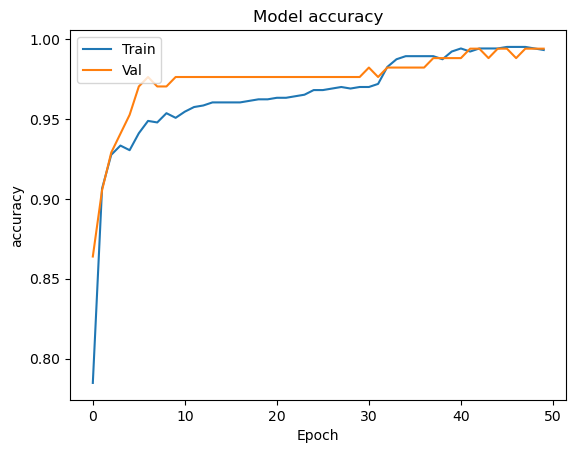

In [70]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [77]:
sample = X_test[43:44]
prediction = model.predict(sample)
print(prediction)

score = np.max(prediction)
prediction = np.argmax(prediction)

print(f'Передбачено: {prediction} з достовірністю {score*100:.2f}%', f'Повинно бути: {np.argmax(Y_test[43:44])}', sep='\n')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[4.673675e-04 9.995327e-01]]
Передбачено: 1 з достовірністю 99.95%
Повинно бути: 1


In [72]:
model.save('islegendary.keras')